<a href="https://colab.research.google.com/github/Pradeep-Kumar-Panga/DecodingComplexities/blob/main/BayesianInference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Inference
Bayesian Inference is a method to update the probability of a hypothesis as new evidence or data becomes available.

It works based on Bayes Theorem:

P(A|B) = P(B|A) × P(A) / P(B)

**P(A|B) (Posterior)** - The probability of event A occurring given that B has already occurred.  
**P(B|A) (Likelihood)** - The probability of event B occurring given that A has already occurred.  
**P(A) (Prior)** - The prior knowledge about the event occurring irrespective of what data says.  
**P(B) (Evidence)** - The new information that the data is providing.  

Here is a link for the video and blog post to understand more about Bayesian Inference and runthrough of this code.

https://youtu.be/r3qTE9fpHt0  
https://www.pradeeppanga.com/2026/02/bayesian-inference.html


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Define the X-axis (Probability of Heads from 0 to 1)
x = np.linspace(0, 1, 1000)

## Prior Knowledge
Take an example of a fair coin and generate the data.  
**beta.pdf** creates bell curve centered at 0.5

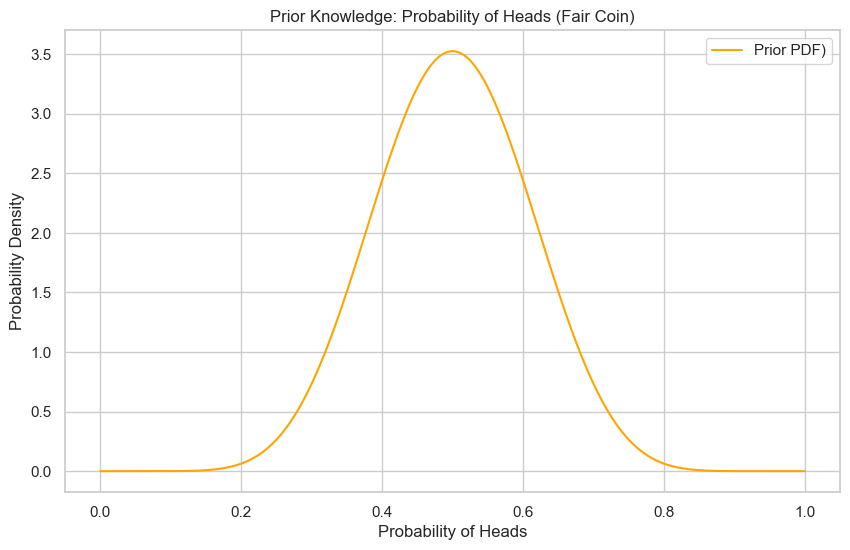

In [ ]:
prior_alpha = 10
prior_beta = 10
prior_pdf = beta.pdf(x, prior_alpha, prior_beta)

# Add code to visualize the prior
plt.figure() # Create a new figure for this plot
plt.plot(x, prior_pdf, color='orange', label=f'Prior PDF)')
plt.title('Prior Knowledge: Probability of Heads (Fair Coin)')
plt.xlabel('Probability of Heads')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## Generate Small Data
Generate data with 5 coin flips, which would show bias either towards Heads or Tails.

With limited data, we calculate:
- **MLE (Maximum Likelihood Estimate)** - The parameter value that maximizes the likelihood of observing the data
- **MAP (Maximum A Posteriori)** - The parameter value that maximizes the posterior probability, combining prior belief with observed data


In [ ]:
num_flips = 5
simulated_flips = np.random.binomial(n=1, p=0.5, size=num_flips)
heads = np.sum(simulated_flips)
tails = num_flips - heads

print(f"Simulated {num_flips} flips: {heads} Heads, {tails} Tails")

mle_estimate = heads / num_flips

post_alpha = prior_alpha + heads
post_beta = prior_beta + tails
posterior_pdf = beta.pdf(x, post_alpha, post_beta)

if post_alpha > 1 and post_beta > 1:
    map_estimate = (post_alpha - 1) / (post_alpha + post_beta - 2)
else:
    if post_alpha <= 1 and post_beta <= 1:
        map_estimate = np.nan
    elif post_alpha <= 1:
        map_estimate = 0
    else:
        map_estimate = 1


print(f"MLE Estimate: {mle_estimate:.4f}")
print(f"MAP Estimate: {map_estimate:.4f}")

Simulated 5 flips: 3 Heads, 2 Tails
MLE Estimate: 0.6000
MAP Estimate: 0.5217


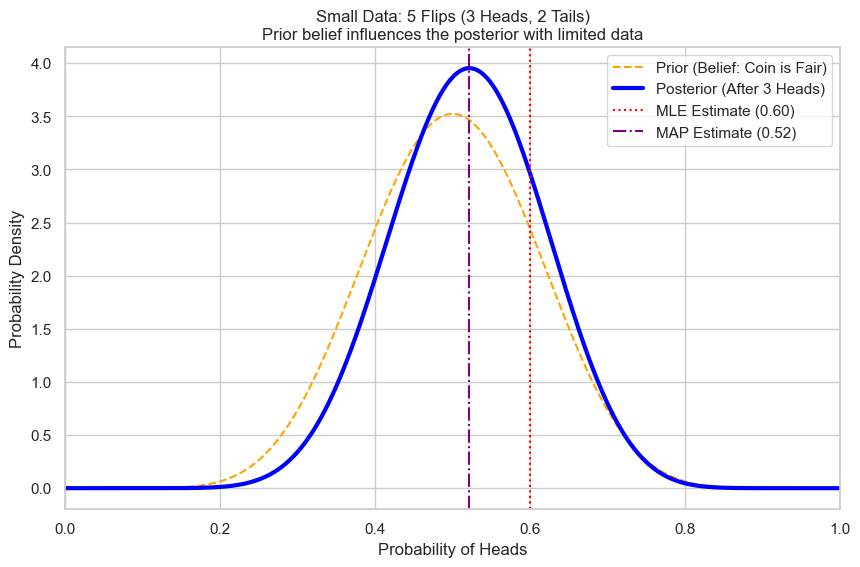

In [ ]:
# Visualization for Small Data Scenario
plt.figure(figsize=(10, 6))
plt.plot(x, prior_pdf, 'orange', linestyle='--', label='Prior (Belief: Coin is Fair)')
plt.plot(x, posterior_pdf, 'blue', linewidth=3, label=f'Posterior (After {heads} Heads)')
plt.axvline(mle_estimate, color='red', linestyle=':', label=f'MLE Estimate ({mle_estimate:.2f})')
plt.axvline(map_estimate, color='purple', linestyle='-.', label=f'MAP Estimate ({map_estimate:.2f})')
plt.title(f"Small Data: {num_flips} Flips ({heads} Heads, {tails} Tails)\nPrior belief influences the posterior with limited data")
plt.xlabel('Probability of Heads')
plt.ylabel('Probability Density')
plt.xlim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## Generate Large Data
Generate data with 100 coin flips to demonstrate how more data influences the posterior.


In [ ]:
# Simulate 100 coin flips
num_big_flips = 100
simulated_big_flips = np.random.binomial(n=1, p=0.5, size=num_big_flips)
heads_big = np.sum(simulated_big_flips)
tails_big = num_big_flips - heads_big

print(f"Simulated {num_big_flips} flips: {heads_big} Heads, {tails_big} Tails")

# Update belief (posterior) using the prior and the new data
big_alpha = prior_alpha + heads_big
big_beta = prior_beta + tails_big
big_data_pdf = beta.pdf(x, big_alpha, big_beta)


Simulated 100 flips: 60 Heads, 40 Tails


MLE Estimate: 0.6000
MAP Estimate: 0.5847


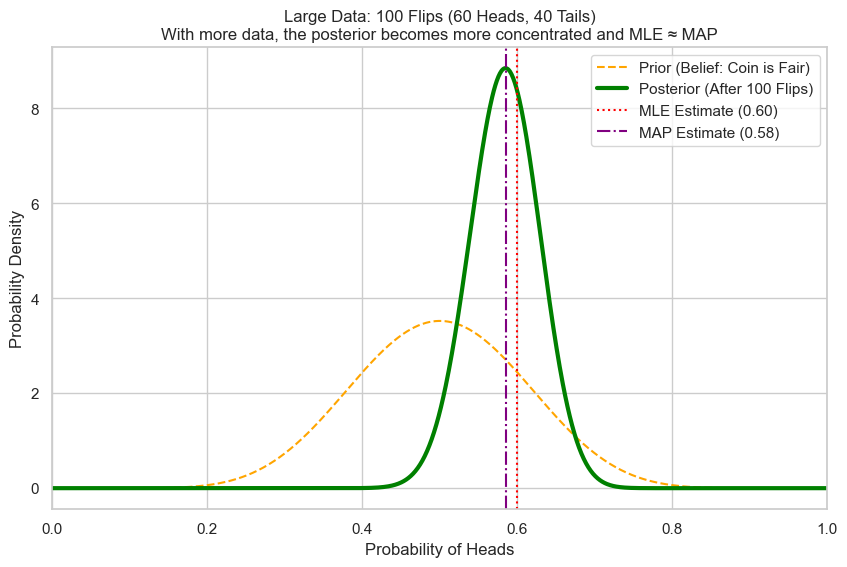

In [ ]:
# Calculate MLE and MAP for large data
mle_estimate_big = heads_big / num_big_flips

if big_alpha > 1 and big_beta > 1:
    map_estimate_big = (big_alpha - 1) / (big_alpha + big_beta - 2)
else:
    if big_alpha <= 1 and big_beta <= 1:
        map_estimate_big = np.nan
    elif big_alpha <= 1:
        map_estimate_big = 0
    else:
        map_estimate_big = 1

print(f"MLE Estimate: {mle_estimate_big:.4f}")
print(f"MAP Estimate: {map_estimate_big:.4f}")

# Visualization for Large Data Scenario
plt.figure(figsize=(10, 6))
plt.plot(x, prior_pdf, 'orange', linestyle='--', label='Prior (Belief: Coin is Fair)')
plt.plot(x, big_data_pdf, 'green', linewidth=3, label=f'Posterior (After {num_big_flips} Flips)')
plt.axvline(mle_estimate_big, color='red', linestyle=':', label=f'MLE Estimate ({mle_estimate_big:.2f})')
plt.axvline(map_estimate_big, color='purple', linestyle='-.', label=f'MAP Estimate ({map_estimate_big:.2f})')
plt.title(f"Large Data: {num_big_flips} Flips ({heads_big} Heads, {tails_big} Tails)\nWith more data, the posterior becomes more concentrated and MLE ≈ MAP")
plt.xlabel('Probability of Heads')
plt.ylabel('Probability Density')
plt.xlim(0, 1)
plt.legend()
plt.grid(True)
plt.show()